In [111]:
import os
import sys
sys.path.append(os.path.expanduser('~'))
import numpy as np 
from matplotlib import pyplot as plt
from datetime import datetime as dt
import figures as fgs
from albatros_analysis.src.correlations import baseband_data_classes as bdc
from albatros_analysis.src.utils import baseband_utils as butils
from albatros_analysis.src.utils import orbcomm_utils as outils
import numba as nb
import time
import importlib
import json
from pyuvdata import UVData

BDC is using numpy


In [114]:
config_path = '/home/thomasb/albatros_analysis/scripts/xcorr/config/config_bright_test.json'
disk_path = '/scratch/thomasb/xcorr_all_ant_1bit_1753216650_1753217000_512_64_325_1834_1852.uvh5'

In [115]:
#open config and get metadata
with open(config_path, "r") as f:
    config = json.load(f)
ant_names, ant_coords, dir_parents, spec_offsets = [], [], [], []
# Call get_starting_index for all antennas except reference
for i, (ant, details) in enumerate(config["antennas"].items()):
    dir_parents.append(details["path"])
    spec_offsets.append(details["clock_offset"])
    ant_names.append(details["name"])
    ant_coords.append(details["coordinates"])

ant_numbers = np.array([int(name.split()[1]) for name in ant_names])
batch_start_ts = config["correlation"]["start_timestamp"]
batch_end_ts = config["correlation"]["end_timestamp"]
chanstart = config["frequency"]["start_channel"]
chanend = config["frequency"]["end_channel"]
osamp = config["correlation"]["osamp"]
pfb_size = config["correlation"]["pfb_size"]
new_acclen = config["correlation"]["new_acclen"]

new_chunk_len = (new_acclen*4096*osamp)/250e6
tle_path = outils.get_tle_file(batch_start_ts, "/project/rrg-sievers/mohanagr/OCOMM_TLES")
print(new_acclen)

512


In [116]:
uv = UVData()
uv.read(disk_path)
print(uv)

The uvw_array does not match the expected values given the antenna positions. The largest discrepancy is 15162.725505130295 meters. This is a fairly common situation but might indicate an error in the antenna positions, the uvws or the phasing.
Fixing auto-correlations to be be real-only, after some imaginary values were detected in data_array. Largest imaginary component was 42.917842864990234, largest imaginary/real ratio was 1193408.004670663.


In [117]:
uv.integration_time[0] - (new_acclen*(4096/250e6)*osamp)
uv.Nfreqs

1152

In [118]:
freqs = (np.arange(uv.Nfreqs)/64 + 1834)*250e6/4096
freqs = 250e6-freqs
print(freqs.shape)
print(freqs[140])
for freq in uv.freq_array:
    print(freq/1000)

(1152,)
137928009.03320312
111938.4765625
111939.4302368164
111940.38391113281
111941.33758544922
111942.29125976562
111943.24493408203
111944.19860839844
111945.15228271484
111946.10595703125
111947.05963134766
111948.01330566406
111948.96697998047
111949.92065429688
111950.87432861328
111951.82800292969
111952.7816772461
111953.7353515625
111954.6890258789
111955.64270019531
111956.59637451172
111957.55004882812
111958.50372314453
111959.45739746094
111960.41107177734
111961.36474609375
111962.31842041016
111963.27209472656
111964.22576904297
111965.17944335938
111966.13311767578
111967.08679199219
111968.0404663086
111968.994140625
111969.9478149414
111970.90148925781
111971.85516357422
111972.80883789062
111973.76251220703
111974.71618652344
111975.66986083984
111976.62353515625
111977.57720947266
111978.53088378906
111979.48455810547
111980.43823242188
111981.39190673828
111982.34558105469
111983.2992553711
111984.2529296875
111985.2066040039
111986.16027832031
111987.11395263672


In [119]:
data_all = uv.data_array
antnums = uv.telescope.antenna_numbers
ant1, ant2 = 5, 7
print(data_all.shape)
print(data_all[-28, 0, 0]) #last row is missing

(18200, 1152, 4)
0j


In [120]:
ant1_idx, ant2_idx = np.where(antnums == ant1)[0][0], np.where(antnums == ant2)[0][0]
coords1, coords2 = ant_coords[ant1_idx], ant_coords[ant2_idx]
name1, name2 = ant_names[ant1_idx], ant_names[ant2_idx]

bl_slice = uv.antpair2ind(ant1, ant2)
print(bl_slice)
bl_data = data_all[bl_slice, :, 0]
print(bl_data.shape)
bl_angle = np.angle(bl_data)

slice(20, 18220, 28)
(650, 1152)


old_channel: 1836.34375
catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.07758784294128418
time taken pred 0.07794880867004395
MAX PHASE DIFFERENCE: 3.428702457099803


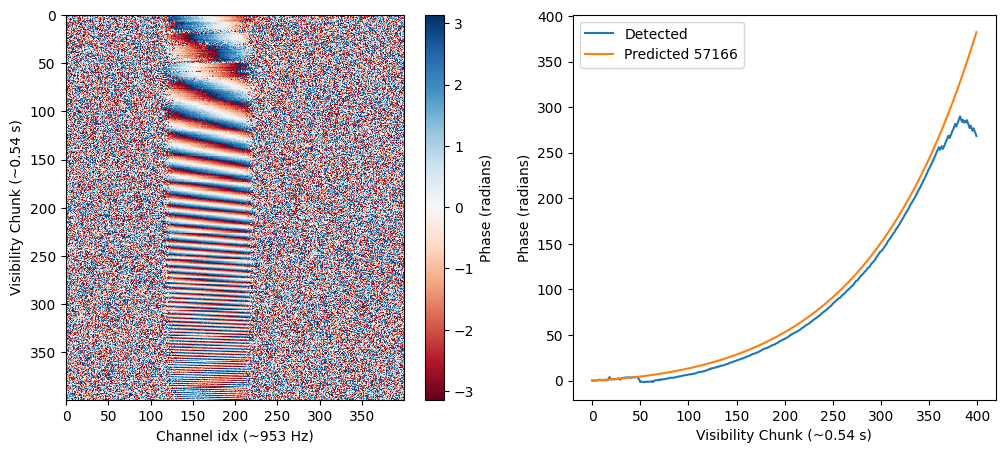

In [122]:
fig = fgs.makeplot_fringes_phase_upsampled(bl_angle[:400, :400], 150, batch_start_ts, batch_end_ts, coords1, coords2)

In [ ]:
for i in range(len(antnums)):
        for j in range(i+1, len(antnums)):
            ai_num = antnums[i]
            aj_num = antnums[j]
            a1_coords = ant_coords[i]
            a2_coords = ant_coords[j]

1 2
188.095 183.51076468
1 4
188.095 19.777
1 5
188.095 59.364
1 6
188.095 42.692
1 7
188.095 32.593
1 8
188.095 416.829
2 4
183.51076468 19.777
2 5
183.51076468 59.364
2 6
183.51076468 42.692
2 7
183.51076468 32.593
2 8
183.51076468 416.829
4 5
19.777 59.364
4 6
19.777 42.692
4 7
19.777 32.593
4 8
19.777 416.829
5 6
59.364 42.692
5 7
59.364 32.593
5 8
59.364 416.829
6 7
42.692 32.593
6 8
42.692 416.829
7 8
32.593 416.829
